<a href="https://colab.research.google.com/github/MaryamFarshbafi/construction-automation-portfolio/blob/main/construction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

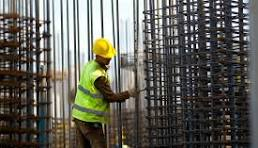

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("claytonmiller/construction-and-project-management-example-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'construction-and-project-management-example-data' dataset.
Path to dataset files: /kaggle/input/construction-and-project-management-example-data


In [45]:
import os
import pandas as pd
print(os.listdir(path))


['Construction_Data_PM_Tasks_All_Projects.csv', 'Construction_Data_PM_Forms_All_Projects.csv']


In [46]:
tasks_file= os.path.join(
    path,
    "Construction_Data_PM_Tasks_All_Projects.csv"

)

In [47]:
df= pd.read_csv(tasks_file)
df.head()

,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety


In [48]:
print("Number of the row: " , df.shape[0])
print("Number of the column: " , df.shape[1])

print("\nColumn name: ")
for col in df.columns:
    print(col)

Number of the row:  12424
Number of the column:  19

Column name: 
Ref
Status
Location
Description
Created
Target
Type
To Package
Status Changed
Association
OverDue
Images
Comments
Documents
Priority
Cause
project
Report Status
Task Group


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12424 entries, 0 to 12423
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ref             12424 non-null  object 
 1   Status          12424 non-null  object 
 2   Location        12424 non-null  object 
 3   Description     12424 non-null  object 
 4   Created         12424 non-null  object 
 5   Target          2568 non-null   float64
 6   Type            12424 non-null  object 
 7   To Package      11382 non-null  object 
 8   Status Changed  12424 non-null  object 
 9   Association     9483 non-null   object 
 10  OverDue         12424 non-null  bool   
 11  Images          12272 non-null  object 
 12  Comments        11902 non-null  object 
 13  Documents       11780 non-null  object 
 14  Priority        2366 non-null   object 
 15  Cause           9683 non-null   object 
 16  project         12424 non-null  int64  
 17  Report Status   12424 non-null 

In [50]:
important_columns = [
    "Ref",
    "Status",
    "Location",
    "Created",
    "Target",
    "Type",
    "To Package",
    "OverDue",
    "Priority",
    "project"
]

df[important_columns].head(10)

,Ref,Status,Location,Created,Target,Type,To Package,OverDue,Priority,project
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,False,Behavioural Failure,1328
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,False,NaN,1328
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,False,NaN,1328
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,False,NaN,1328
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,False,NaN,1328
5,T116412.198,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,14/09/2020,NaN,JPC - Progress Photo,Roofing,False,NaN,1328
6,T141663.25,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Ceilings & Partitions,False,NaN,1328
7,T116412.197,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,14/09/2020,NaN,JPC - Progress Photo,Cladding & Roofing,False,NaN,1328
8,T141663.24,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,False,NaN,1328
9,T141663.23,Open,JPC Project Management>EHS Management>01 Inspe...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,False,NaN,1328


In [51]:
df.head()

,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety


In [52]:
df[["Status", "Priority", "OverDue"]].head()

,Status,Priority,OverDue
0,Open,Behavioural Failure,False
1,Closed,NaN,False
2,EHS Good Observation,NaN,False
3,Closed,NaN,False
4,EHS Good Observation,NaN,False


In [53]:
# print missing value in any column
print("Missing value in any column: " , df.isnull().sum())
#prin missing value anywhrtr in dataset
print("Missing value in anywhere in dataset: " , df.isnull().values.any())
print(" Adjusting missing value: ", df.isnull().sum().sort_values(ascending=False))
#print duplicate in dataset
print("Duplicate in dataset: " , df.duplicated().sum())
#print sum as whole
print("sum as all: ", df.isnull().sum().sum())
print("Total rows:", len(df))
print("Unique Ref values:", df["Ref"].nunique())

Missing value in any column:  Ref                   0
Status                0
Location              0
Description           0
Created               0
Target             9856
Type                  0
To Package         1042
Status Changed        0
Association        2941
OverDue               0
Images              152
Comments            522
Documents           644
Priority          10058
Cause              2741
project               0
Report Status         0
Task Group           50
dtype: int64
Missing value in anywhere in dataset:  True
 Adjusting missing value:  Priority          10058
Target             9856
Association        2941
Cause              2741
To Package         1042
Documents           644
Comments            522
Images              152
Task Group           50
Ref                   0
Status                0
Location              0
OverDue               0
Created               0
Type                  0
Description           0
Status Changed        0
project               

In [54]:
# Save duplicates for later review if any exsit. in dataset we have zero whoever we create it as showing it case
duplicates = df[df.duplicated()]
# Remove exact duplicate rows
clean_df = df.drop_duplicates().copy()
# Save the cleaned file
clean_df.to_csv("cleaned_tasks.csv", index=False)

In [55]:
display(clean_df.head())

,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety


In [56]:
# just show important attribute
clean_df[
    ["Ref", "Status", "Created", "Target",
     "Type", "To Package", "OverDue",
     "Priority", "project", "Task Group"]
].head(10)

,Ref,Status,Created,Target,Type,To Package,OverDue,Priority,project,Task Group
0,T1.23963030,Open,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,False,Behavioural Failure,1328,Safety
1,T116412.200,Closed,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,False,NaN,1328,Site Management
2,T141663.27,EHS Good Observation,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,False,NaN,1328,Safety
3,T116412.199,Closed,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,False,NaN,1328,Site Management
4,T141663.26,EHS Good Observation,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,False,NaN,1328,Safety
5,T116412.198,Closed,14/09/2020,NaN,JPC - Progress Photo,Roofing,False,NaN,1328,Site Management
6,T141663.25,EHS Good Observation,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Ceilings & Partitions,False,NaN,1328,Safety
7,T116412.197,Closed,14/09/2020,NaN,JPC - Progress Photo,Cladding & Roofing,False,NaN,1328,Site Management
8,T141663.24,EHS Good Observation,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,False,NaN,1328,Safety
9,T141663.23,Open,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,False,NaN,1328,Safety


In [57]:
clean_df["Created"] = pd.to_datetime(
    clean_df["Created"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [58]:
clean_df["Status Changed"] = pd.to_datetime(
    clean_df["Status Changed"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [59]:
print(clean_df["Target"].notna().sum())
print(clean_df["Target"].dropna().head(20))

2568
20    44094.0
21    44094.0
22    44091.0
35    44091.0
36    44091.0
37    44091.0
38    44091.0
48    44090.0
50    44090.0
51    44090.0
53    44090.0
54    44089.0
55    44089.0
56    44089.0
57    44089.0
58    44089.0
59    44089.0
60    44089.0
61    44089.0
62    44089.0
Name: Target, dtype: float64


In [60]:
quality_report = pd.DataFrame({
    "Missing_Count": clean_df.isnull().sum(),
    "Missing_Percent": (
        clean_df.isnull().sum() / len(clean_df) * 100
    ).round(2)
})

quality_report = quality_report.sort_values(
    "Missing_Percent",
    ascending=False
)

display(quality_report)

,Missing_Count,Missing_Percent
Priority,10058,80.96
Target,9856,79.33
Association,2941,23.67
Cause,2741,22.06
To Package,1042,8.39
Documents,644,5.18
Comments,522,4.20
Images,152,1.22
Task Group,50,0.40
Ref,0,0.00


In [61]:
display(clean_df.head())

,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,2020-09-14,NaN,Safety Notice (Amber) - General Issue,Main Contractor,2020-09-14,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,2020-09-14,NaN,JPC - Progress Photo,Ceilings & Partitions,2020-09-14,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,2020-09-14,NaN,Safety Notice (Green) - Good Observation,Main Contractor,2020-09-14,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,2020-09-14,NaN,JPC - Progress Photo,Precast Concrete,2020-09-14,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",2020-09-14,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,2020-09-14,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety


In [62]:
# print missing value in any column
print("Missing value in any column: " , clean_df.isnull().sum())
#prin missing value anywhrtr in dataset
print("Missing value in anywhere in dataset: " , clean_df.isnull().values.any())
print(" Adjusting missing value: ", clean_df.isnull().sum().sort_values(ascending=False))
#print duplicate in dataset
print("Duplicate in dataset: " , clean_df.duplicated().sum())
#print sum as whole
print("sum as all: ", clean_df.isnull().sum().sum())
print("Total rows:", len(clean_df))
print("Unique Ref values:", clean_df["Ref"].nunique())

Missing value in any column:  Ref                   0
Status                0
Location              0
Description           0
Created               0
Target             9856
Type                  0
To Package         1042
Status Changed        0
Association        2941
OverDue               0
Images              152
Comments            522
Documents           644
Priority          10058
Cause              2741
project               0
Report Status         0
Task Group           50
dtype: int64
Missing value in anywhere in dataset:  True
 Adjusting missing value:  Priority          10058
Target             9856
Association        2941
Cause              2741
To Package         1042
Documents           644
Comments            522
Images              152
Task Group           50
Ref                   0
Status                0
Location              0
OverDue               0
Created               0
Type                  0
Description           0
Status Changed        0
project               

Here we find out that it is not different between before and after the cleaning data since we had not duplicate in raw database. So we need to investigate why Priority has so many null and find out about the statuse. We cannot remove the null for this database since the null might have some meaning and we need to investage it to find out the problem.



In [63]:
priority_by_type = (
    df.groupby("Type")
      .agg(
          Total_Tasks=("Ref", "count"),
          Missing_Priority=("Priority", lambda x: x.isna().sum())
      )
)

priority_by_type["Missing_Percent"] = (
    priority_by_type["Missing_Priority"]
    / priority_by_type["Total_Tasks"]
    * 100
).round(2)

display(
    priority_by_type.sort_values(
        "Total_Tasks",
        ascending=False
    ).head(20)
)

,Total_Tasks,Missing_Priority,Missing_Percent
Type,,,
Safety Notice (Amber) - General Issue,5486,3688,67.23
Safety Notice (Green) - Good Observation,3343,3248,97.16
JPC - Progress Photo,666,666,100.00
JPC - Works To Go,506,448,88.54
JPC - Quality Snag (aesthetic),351,297,84.62
Design Team - BCAR Structural,325,275,84.62
JPC - Quality Defect (compliance),298,239,80.20
Design Team - BCAR Architectural,295,263,89.15
Design Team - BCAR Assign Certifier,154,152,98.70


In [64]:
duplicate_refs = df[df["Ref"].duplicated(keep=False)]

display(
    duplicate_refs.sort_values("Ref")[
        ["Ref", "Status", "Created", "Status Changed",
         "Type", "project"]
    ].head(30)
)

,Ref,Status,Created,Status Changed,Type,project
4461,T102314.100,Closed,09/07/2020,25/07/2020,Safety Notice (Amber) - General Issue,1330
3983,T102314.100,Closed,09/07/2020,25/07/2020,Safety Notice (Amber) - General Issue,1329
4460,T102314.101,EHS Good Observation,09/07/2020,09/07/2020,Safety Notice (Green) - Good Observation,1330
3982,T102314.101,EHS Good Observation,09/07/2020,09/07/2020,Safety Notice (Green) - Good Observation,1329
3981,T102314.102,Closed,09/07/2020,13/07/2020,Safety Notice (Amber) - General Issue,1329
4459,T102314.102,Closed,09/07/2020,13/07/2020,Safety Notice (Amber) - General Issue,1330
4458,T102314.103,Closed,09/07/2020,13/07/2020,Safety Notice (Amber) - General Issue,1330
3980,T102314.103,Closed,09/07/2020,13/07/2020,Safety Notice (Amber) - General Issue,1329
4457,T102314.104,EHS Good Observation,09/07/2020,09/07/2020,Safety Notice (Green) - Good Observation,1330
3979,T102314.104,EHS Good Observation,09/07/2020,09/07/2020,Safety Notice (Green) - Good Observation,1329


In [65]:
target_status = (
    df.groupby("Status")
      .agg(
          Total_Tasks=("Ref", "count"),
          Missing_Target=("Target", lambda x: x.isna().sum())
      )
)

target_status["Missing_Percent"] = (
    target_status["Missing_Target"]
    / target_status["Total_Tasks"]
    * 100
).round(2)

display(target_status)

,Total_Tasks,Missing_Target,Missing_Percent
Status,,,
3rd Party Inspection - Closed,1,1,100.00
3rd Party Sign Off - Closed,678,6,0.88
Closed,6135,5647,92.05
Closed JPC Reviewed,69,69,100.00
Complete,30,30,100.00
Delivered - Material onsite,1,0,0.00
EHS Good Observation,3343,3343,100.00
JPC Inspected,29,0,0.00
JPC Sign Off,200,22,11.00


In [66]:
from sqlite3.dbapi2 import connect
import sqlite3

connect = sqlite3.connect("construction.db")

clean_df.to_sql(
    "tasks",
    connect,
    if_exists="replace",
    index=False
)

result = pd.read_sql_query(
    "SELECT COUNT(*) AS total_tasks FROM tasks",
    connect
)

print(result)

   total_tasks
0        12424


In [67]:
df.head(10)

,Ref,Status,Location,Description,Created,Target,Type,To Package,Status Changed,Association,OverDue,Images,Comments,Documents,Priority,Cause,project,Report Status,Task Group
0,T1.23963030,Open,JPC Project Management>EHS Management>01 Inspe...,task raised in incorrect location of this form...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,NaN,NaN,NaN,Behavioural Failure,JPC - Safety - Documentation,1328,Open,Safety
1,T116412.200,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Metsec,14/09/2020,NaN,JPC - Progress Photo,Ceilings & Partitions,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
2,T141663.27,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,Good clear exclusion zones and access through ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Closed,Safety
3,T116412.199,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,RC walls,14/09/2020,NaN,JPC - Progress Photo,Precast Concrete,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
4,T141663.26,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,"block 02 working level has good housekeeping, ...",14/09/2020,NaN,Safety Notice (Green) - Good Observation,Precast Concrete,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - House Keeping,1328,Closed,Safety
5,T116412.198,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,A3 Roofing,14/09/2020,NaN,JPC - Progress Photo,Roofing,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
6,T141663.25,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,operaiver using hand sanitizer points onsite. ...,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Ceilings & Partitions,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Welfare Facilities,1328,Closed,Safety
7,T116412.197,Closed,QC & BC(A)R>ITP 02 Architectural & M&E Service...,Tyvec install,14/09/2020,NaN,JPC - Progress Photo,Cladding & Roofing,14/09/2020,NaN,False,True,False,False,NaN,NaN,1328,Closed,Site Management
8,T141663.24,EHS Good Observation,JPC Project Management>EHS Management>01 Inspe...,number of operative fully pee compliant,14/09/2020,NaN,Safety Notice (Green) - Good Observation,Main Contractor,14/09/2020,FormAnswer,False,False,False,False,NaN,JPC - Safety - PPE,1328,Closed,Safety
9,T141663.23,Open,JPC Project Management>EHS Management>01 Inspe...,doors to pods removed. to be reviewed to ensur...,14/09/2020,NaN,Safety Notice (Amber) - General Issue,Main Contractor,14/09/2020,FormAnswer,False,True,False,False,NaN,JPC - Safety - Access,1328,Open,Safety


In [68]:
print(df.columns.tolist())

['Ref', 'Status', 'Location', 'Description', 'Created', 'Target', 'Type', 'To Package', 'Status Changed', 'Association', 'OverDue', 'Images', 'Comments', 'Documents', 'Priority', 'Cause', 'project', 'Report Status', 'Task Group']


In [69]:
query = """
SELECT status, COUNT(*) AS total_tasks
FROM tasks
GROUP BY status
ORDER BY total_tasks DESC
"""

report = pd.read_sql_query(query, connect)
print(report)

                           Status  total_tasks
0                          Closed         6135
1            EHS Good Observation         3343
2            Open / Ongoing Works          683
3     3rd Party Sign Off - Closed          678
4                            Open          558
5           JPC Sign Off / Closed          473
6                    JPC Sign Off          200
7      Rejected / Action Required          124
8             Closed JPC Reviewed           69
9       Works Complete / Resolved           63
10        JPC Signed Off / Closed           36
11                       Complete           30
12                  JPC Inspected           29
13                   Photo Record            1
14    Delivered - Material onsite            1
15  3rd Party Inspection - Closed            1


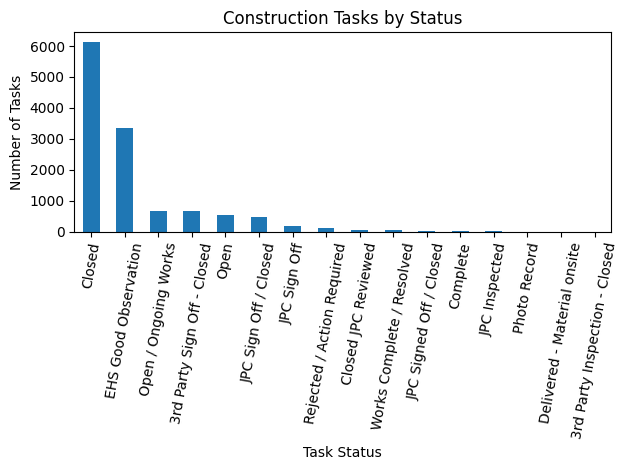

In [70]:
import matplotlib.pyplot as plt

report.plot(
    x="Status",
    y="total_tasks",
    kind="bar",
    legend=False
)

plt.title("Construction Tasks by Status")
plt.xlabel("Task Status")
plt.ylabel("Number of Tasks")
plt.xticks(rotation=80)
plt.tight_layout()

plt.savefig("tasks_by_status.png")
plt.show()

In [71]:
clean_df.to_csv(
    "cleaned_tasks.csv",
    index=False
)

In [72]:
import os

print(os.path.exists("cleaned_tasks.csv"))

True


In [75]:
quality_report = pd.DataFrame({
    "Missing_Count": clean_df.isnull().sum(),
    "Missing_Percent": (
        clean_df.isnull().sum() / len(clean_df) * 100
    ).round(2)
})

quality_report = quality_report.sort_values(
    "Missing_Percent",
    ascending=False
)

quality_report.to_csv(
    "data_quality_report.csv",
    index=True
)

display(quality_report)

,Missing_Count,Missing_Percent
Priority,10058,80.96
Target,9856,79.33
Association,2941,23.67
Cause,2741,22.06
To Package,1042,8.39
Documents,644,5.18
Comments,522,4.20
Images,152,1.22
Task Group,50,0.40
Ref,0,0.00


In [76]:
sql_queries = """
-- Construction Automation Portfolio
-- SQL queries for construction task tracking and reporting


-- Query 1: Total number of tasks
SELECT COUNT(*) AS total_tasks
FROM tasks;


-- Query 2: Number of tasks by status
SELECT
    Status,
    COUNT(*) AS total_tasks
FROM tasks
GROUP BY Status
ORDER BY total_tasks DESC;


-- Query 3: Number of tasks by project
SELECT
    project,
    COUNT(*) AS total_tasks
FROM tasks
GROUP BY project
ORDER BY total_tasks DESC;


-- Query 4: Number of overdue tasks by status
SELECT
    Status,
    COUNT(*) AS overdue_tasks
FROM tasks
WHERE OverDue = 1
GROUP BY Status
ORDER BY overdue_tasks DESC;


-- Query 5: Number of tasks by task group
SELECT
    "Task Group",
    COUNT(*) AS total_tasks
FROM tasks
GROUP BY "Task Group"
ORDER BY total_tasks DESC;
"""

with open("construction_queries.sql", "w") as file:
    file.write(sql_queries)

print("construction_queries.sql created successfully.")

construction_queries.sql created successfully.


In [77]:
import os

print(os.path.exists("construction_queries.sql"))

True


In [78]:
query_project = """
SELECT
    project,
    COUNT(*) AS total_tasks
FROM tasks
GROUP BY project
ORDER BY total_tasks DESC;
"""

project_report = pd.read_sql_query(
    query_project,
    connect
)

display(project_report)

,project,total_tasks
0,1328,3751
1,1330,3684
2,1338,1308
3,1335,1267
4,1340,995
5,1345,560
6,1329,478
7,1343,381


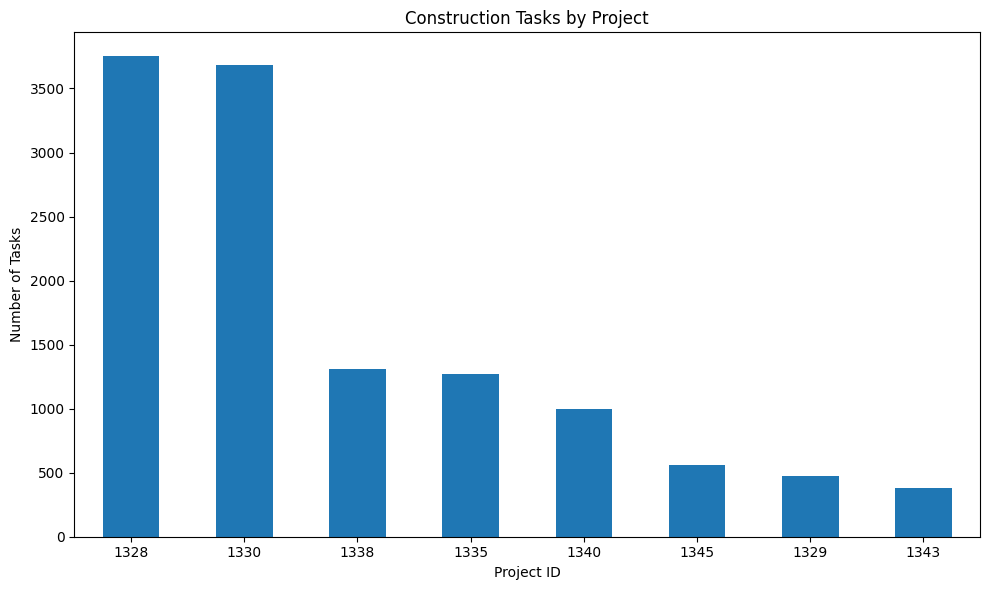

In [79]:
import matplotlib.pyplot as plt

# Convert project IDs to strings so they appear as categories
project_report["project"] = project_report["project"].astype(str)

project_report.plot(
    x="project",
    y="total_tasks",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("Construction Tasks by Project")
plt.xlabel("Project ID")
plt.ylabel("Number of Tasks")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "tasks_by_project.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
import os

print(os.path.exists("tasks_by_project.png"))

True
